# Phase 2 - Patients Clustering

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 2 (Unsupervised Learning)

# The Notebook Overview




## 1. Clustering Rationale & Algorithm Selection
In this section, we will justify the choice of each .....?...... 

## 2. Data Preparation 

### 2.1 Feature Scaling
Feature scaling is important in clustering because most clustering algorithms rely on distance calculations to measure similarity between data points. When variables are measured on different scales, features with larger numerical ranges can dominate the distance computation, leading to biased clustering results. For example, a variable such as RestingBP may have larger values compared to Oldpeak, causing it to have a disproportionate influence on cluster formation if not scaled.

Applying feature scaling ensures that all numerical variables contribute equally to the clustering process, allowing clusters to reflect meaningful patterns in the data rather than differences in measurement scale.
In this study, feature scaling was applied during preprocessing to continuous variables, including Age, MaxHR, Oldpeak, and RestingBP.

### 2.2 Target Removal

Target removal is necessary in clustering because it is an unsupervised learning task. This means the model should discover patterns and group similar data points without using any predefined labels.
Including the target variable may bias the clustering results, as it would indirectly guide the model toward known outcomes instead of uncovering natural structures in the data.

### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display
from sklearn.cluster import KMeans
import holoviews as hv
from holoviews import opts
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import seaborn as sns 
import numpy as np
import warnings
import prince
import hdbscan


### Load Preprocessed Dataset & Remove Target

In [128]:
# Load dataset including target from supervised lerning phase
DATA_PATH = "Dataset/preprocessed_heart_data.csv"
original_data = pd.read_csv(DATA_PATH)

print(f"Dataset (with target): {original_data.shape}")

# Remove target column for clustering (unsupervised learning)
clustering_data = original_data.drop(columns=["HeartDisease"])

print(f"Clustering data shape: {clustering_data.shape}")

# Save clustering dataset
clustering_data.to_csv("Dataset/clustering_data.csv", index=False)
print("Clustering dataset saved as 'clustered_data.csv'")

Dataset (with target): (917, 21)
Clustering data shape: (917, 20)
Clustering dataset saved as 'clustered_data.csv'


### Load Clustering Dataset

In [293]:
# The dataset is already cleaned and preprocessed from the EDA phase
clustering_data = pd.read_csv("Dataset/clustering_data.csv")

print(f"Loaded clustering data: {clustering_data.shape}")
clustering_data.head()

Loaded clustering data: (917, 20)


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,0,0,1,0,0,0,1,1,0,0


### MCA-Transformed Space

Multiple Correspondence Analysis (MCA) was applied to transform the one-hot encoded categorical variables into a continuous, low-dimensional representation, allowing each observation to be expressed as a point in a geometric space (Abdi, 2007). In this representation, distances between points reflect similarities between categorical profiles, enabling meaningful comparisons across observations. As highlighted in prior work, MCA provides a structured way to analyze categorical data by preserving relationships between variables and representing them in a coordinate system (Abdi, 2007).

This transformation makes the data suitable for clustering algorithms that rely on Euclidean distance, which require continuous numerical input and benefit from meaningful geometric representations. Previous studies have shown that clustering can be effectively performed on the coordinates derived from MCA to identify meaningful groupings within the data (Carrasco-Bonal et al., 2025). Furthermore, MCA is widely used in categorical data analysis across various domains, including healthcare, where it has been applied to explore patient characteristics and uncover patterns in clinical datasets (Greenacre, 2017).


>Abdi, H. (2007). Multiple Correspondence Analysis.
>https://www.utdallas.edu/~herve/Abdi-MCA2007-pretty.pdf
>
>Carrasco-Bonal, R., et al. (2025). Multiple Correspondence Analysis and Clustering.
>https://www.mdpi.com/2227-7390/13/22/3574
>
>Greenacre, M. (2017). Correspondence Analysis in Practice.
>https://doi.org/10.1201/9781315369983


In [298]:
# 1. Uses one-hot encoded categorical variables
# 2. Applies MCA for dimensionality reduction
# 3. Runs clustering algorithm 
# 4. Evaluates clustering
# 5. Maps cluster labels back to ORIGINAL data
# 6. Interprets clusters using grouped one-hot features

# Copy original dataset
clustered_patient_data = clustering_data.copy()

# Define categorical features
cp_cols = [
    'ChestPainType_ASY',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA'
]

restecg_cols = [
    'RestingECG_LVH',
    'RestingECG_Normal',
    'RestingECG_ST'
]

st_cols = [
    'ST_Slope_Down',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

chol_cols = [
    'Chol_category_Desirable',
    'Chol_category_Borderline High', 
    'Chol_category_High'
]

# INCLUDE binary features here
binary_cols = ['Sex', 'ExerciseAngina']

# Combine ALL categorical features
categorical_cols = binary_cols + cp_cols + restecg_cols + st_cols + chol_cols

df_cat = clustered_patient_data[categorical_cols]

# Apply MCA
mca = prince.MCA(
    n_components=3,
    n_iter=100,
    random_state=42
)

clustering_data_MCA = mca.fit_transform(df_cat)

# FINAL NOTE:
# - MCA is used ONLY for clustering
# - Cluster labels are mapped back to original data
# - Interpretation is done using grouped one-hot features


## 3. Cluster Determination & Implementation

- Determine the optimal number of clusters.
- Apply clustering and assign cluster labels.

## 4. Evaluation Metrics & Visualizations
- Evaluate cluster quality using:
  - Silhouette Score
  - Davies-Bouldin Index
  - Within-Cluster Sum of Squares (WCSS)
  - BCubed Precision/Recall (optional, for external validation if ground truth exists)
- Visualize clusters:
  - PCA/t-SNE for 2D/3D projection of clusters
  - Feature importance per cluster
  - Cluster size distribution

## 5. Cluster Interpretation & Profiles
  - Profile each cluster: What characterizes each group?
  - Relate clusters to your domain: What do these groups mean for your advice system?

## 6. Integration Strategy (how clusters will enhance the system)
  - Integration proposal. If integration is not feasible, provide a detailed, justified explanation.

## 7. Challenges & Limitations

---

# **K-means**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is K-means Algorithm?**
K-Means is a centroid-based clustering algorithm that partitions a dataset into *K* distinct clusters by minimizing the Within-Cluster Sum of Squares (WCSS). It is designed for numerical data, where similarity between data points is measured using a distance mesuare typically Euclidean distance. The algorithm aims to group similar observations together while keeping clusters as compact as possible.

### **Distance Metric**

K-Means uses Euclidean distance to measure similarity:

$$
d(x, \mu) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_j)^2}
$$

- $n$ represents the total number of features.
- $x_j$ is the value of a specific feature.
- $\mu_j$ is the value of the cluster's average for that same feature.

### **How K-Means Works ?**

K-Means follows an iterative optimization process:

1. Initialize *K* cluster centroids randomly  
2. Assign each data point to the nearest centroid  
3. Update each centroid as the mean of its assigned points  
4. Repeat until convergence where cluster assignments stabilize


The algorithm minimizes the Within-Cluster Sum of Squares (WCSS):

$$
\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

- \($C_i$) is cluster \(i\)  
- \($x$) is a data point  
- \($\mu_j$) is the centroid of cluster \(i\)

This objective ensures that data points within the same cluster are as close as possible to their centroid.

---

### **Why is K-Means suitable for our data?**

#### i. Dataset size & feature types

The dataset contains 917 samples and 20 features, originally combining both numerical and categorical variables. However, all categorical features were transformed using One-Hot Encoding, resulting in binary (0/1) variables. This transformation converts the dataset into a fully numerical representation, where all features wether continuous or binary can be processed within a unified distance-based measure.

Numerical features (such as age, resting blood pressure, maximum heart rate, and oldpeak) were scaled to ensure balanced contribution in distance calculations. At the same time, categorical variables (e.g., chest pain type, ECG results, ST slope, cholesterol category) are one-hot encoded and are represented as binary dimensions, preserving their informational content while making them compatible with numerical distance based algorithms. This transformation justifies the use of K-Means, which relies on Euclidean distance and requires numerical input. In our setting where continuous features capture physiological variation and binary features captures categorical distinctions, all features contribute jointly to distance computation.  Thus, both types of medical information are incorporated without requiring separate dissimilarity measures.

A key consideration is the presence of outliers in numerical features, such as Resting Blood Pressure and Oldpeak. As a centroid-based method, K-Means is sensitive to such values because cluster centers are computed using the mean (Han et al., 2011). However, unlike standard preprocessing pipelines that might employ capping or deletion of outliers, we retained extreme values to preserve potential signals of high-risk clinical pathologies. These outliers often represent the most medically significant findings and are essential for a representative clustering of patient risk.

---

#### ii. Expected cluster shapes

Cluster shape expectations depend on both the algorithm and the structure of the data. K-Means, as a centroid-based algorithm, assumes that clusters are compact and approximately spherical in the feature space, as it minimizes the Within-Cluster Sum of Squares (WCSS) using Euclidean distance (Bishop, 2006).

This assumption may be restrictive in datasets with highly irregular or non-convex structures. However, it is reasonable for the current medical dataset for several reasons. The data represents structured clinical attributes rather than spatial or image-based patterns and similar patients tend to have similar feature values across multiple dimensions. Although One-Hot Encoding increases dimensionality, the resulting binary features still contribute meaningfully to distance by separating categorical states across dimensions. This leads to clusters that reflect similarity in overall patient profiles, rather than relying on a single dominant feature.

It is important to note that medical data may exhibit some degree of overlap between patient groups. While K-Means enforces hard boundaries between clusters, the resulting partitions can still provide useful approximations of underlying patient subgroups, particularly when interpreted with awareness of this limitation. Overall, the assumption of compact clusters aligns with the nature of the dataset, where patients with similar physiological and clinical characteristics are expected to group together in a structured and interpretable manner.

---


#### iii. Scalability & Interpretability

**Scalability** refers to the ability of a clustering algorithm to efficiently handle increasing data size and dimensionality. K-Means demonstrates strong scalability due to its simple and iterative structure, where each iteration consists of assigning data points to the nearest centroid and updating centroids accordingly.

The computational complexity of K-Means is :

$$
\mathcal{O}(n \cdot k \cdot d)
$$

- \(n\) is the number of data points  
- \(k\) is the number of clusters  
- \(d\) is the number of features  

This makes K-Means highly efficient and suitable for datasets with moderate to large size.

In our case, the use of One-Hot Encoding increases the dimensionality of the dataset due to the expansion of categorical variables into multiple binary features. Despite this increase, K-Means remains scalable because:

- Binary features (0/1) are computationally inexpensive to process  
- Distance calculations remain efficient even in higher dimensions  
- The algorithm scales linearly with both data size and number of features  


**Interpretability** refers to how easily the resulting clusters can be understood and explained. In K-Means, each cluster is represented by its centroid, defined as the mean of all data points within the cluster:

$$
\mu_j = \frac{1}{|C|} \sum_{x \in C} x_j
$$

* $\mu_j$: The new center (mean) of the cluster
* $|C|$: The number of points in the cluster
* $\sum x_j$: The sum of all points in that cluster

For one-hot encoded variables, centroid values lie between 0 and 1, which can be interpreted as:
- values close to 1 → the category is dominant in the cluster  
- values close to 0 → the category is rare in the cluster  

This means each cluster is described by the average values of numerical features (e.g., Oldpeak, Resting Blood Pressure) and binary (one-hot) features, which reflects the proportion of patients belonging to each category. Overall, K-Means provides a transparent and interpretable representation of clusters, which is particularly important in medical analysis, where understanding patient group characteristics is essential for decision-making.

---

> Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques*.  
> https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques  
>
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
> https://link.springer.com/book/10.1007/978-0-387-45528-0

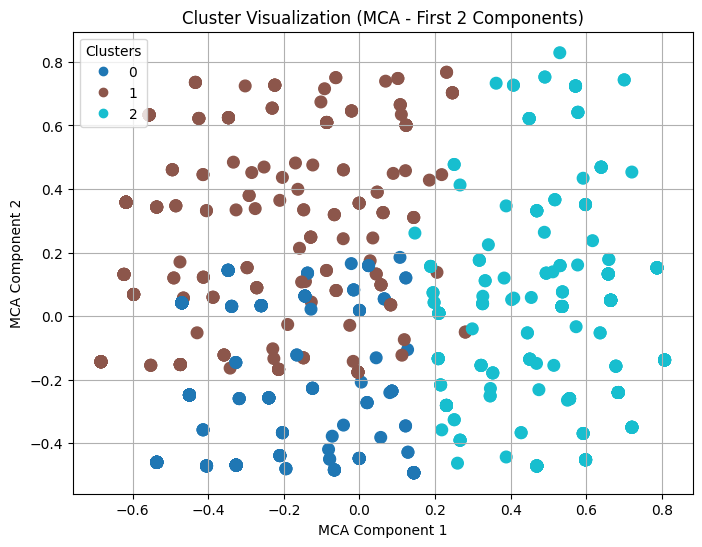

In [291]:
import matplotlib.pyplot as plt

X_plot = clustering_data_MCA.values 

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=labels,
    cmap='tab10',   
    s=70,          
)

# legend للclusters
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.xlabel("MCA Component 1")
plt.ylabel("MCA Component 2")
plt.title("Cluster Visualization (MCA - First 2 Components)")

plt.grid(True)
plt.show()

## Section 3. Cluster Determination & Implementation

### 3.1 Sensitivity to Initialization and the K-Means++ Optimization

A significant challenge in centroid-based clustering is the sensitivity to initial centroid selection. Standard algorithms often begin by selecting initial cluster centers at random, however, because the final partitions are determined iteratively from these starting points, the algorithm is prone to converging on local optima. In a medical context, this stochastic nature can result in unstable clusters that vary between runs or fail to capture the true underlying structure of the patient data. To resolve this instability and ensure the reproducibility of our patient subgroups, we utilize K-Means++ initialization method (Arthur & Vassilvitskii, 2007). Unlike naive random selection, K-Means++ implements a probabilistic seeding strategy designed to spread initial centroids across the entire feature space.

The algorithm selects the first center at random, but each subsequent center is chosen from the remaining data points with a probability proportional to the squared distance from the nearest existing center, This "spread-out" approach ensures that the initial seeds are not clustered in a single high-density region of the dataset, which is particularly vital given the high dimensionality and natural overlap of cardiovascular symptoms.

Furthermore, a high initialization count ($n\_init=50$) is employed, allowing the algorithm to converge on the global minimum of the objective function rather than getting trapped in suboptimal local minima. Additionally, a fixed random_state is implemented to ensure reproducibility where without this parameter, the stochastic nature of the starting points could result in slightly different cluster assignments upon each execution. By combining these rigorous initialization parameters, the model achieves a robust and clinically interpretable segmentation of patient risks that remains consistent across multiple iterations.

>  **Arthur, D., & Vassilvitskii, S. (2007).** *k-means++: The advantages of careful seeding*. Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, 1027–1035.


### 3.2 High-Dimensionality

A challenge in k-means clusteing ecpeccily for clustering clinical data is the high dimensionality of the feature space. While dimensionality reduction techniques (such as PCA or aggressive feature dropping) are common in data science to simplify models, we intentionally retains the full set of 20 clinical features. As making arbitrary decisions to exclude specific variables could lead to the loss of subtle but critical signals. Medical pathologies are rarely defined by a single variable as they emerge from the complex, non-linear interactions between multiple physiological indicators. By maintaining high-dimensional integrity, the K-Means algorithm is allowed to discover these multifaceted patient profiles without being biased by non-expert assumptions.

### 3.3 Choosing appropratie cluster size ( k )

#### **i. The Elbow method**

The Elbow method is a commonly used technique to determine the optimal number of clusters in clustering algorithms. It works by running the clustering algorithm for different values of k and measuring the clustering cost (the total dissimilarity between data points and their assigned cluster centroids), which reflects how well the data points fit within their assigned clusters. As the number of clusters increases, the clustering cost generally decreases because data points are grouped more precisely. However, beyond a certain point, the improvement becomes marginal.
The Elbow method identifies the optimal number of clusters as the point where the rate of decrease in cost sharply changes, forming a shape similar to an “elbow” in the curve. This point represents a balance between achieving low cost and avoiding unnecessary model complexity.

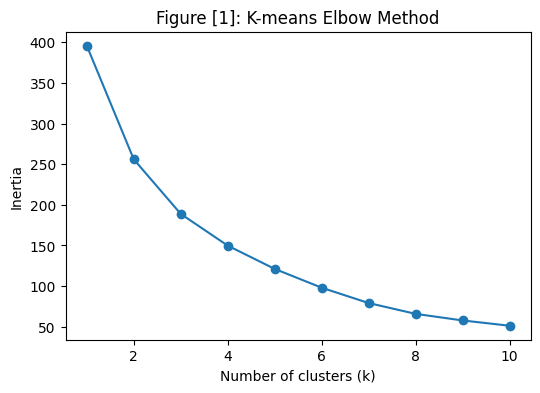

In [299]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100, init='k-means++')
    kmeans.fit(clustering_data_MCA)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure [1]: K-means Elbow Method")
plt.show()

--------------------

### 3.4 Applying clustering and assigning cluster labels


In [300]:
# K-means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++',
    n_init=100
)

# Fit the model and predict cluster labels
labels = kmeans.fit_predict(clustering_data_MCA)

# Assign cluster labels to the original copy of the dataset
clustered_patient_data["cluster"] = labels

# Interpretation tables for later cluster profiling
cp_table = clustered_patient_data.groupby("cluster")[cp_cols].mean()
chol_table = clustered_patient_data.groupby("cluster")[chol_cols].mean()
st_table = clustered_patient_data.groupby("cluster")[st_cols].mean()
restecg_table = clustered_patient_data.groupby("cluster")[restecg_cols].mean()
binary_table = clustered_patient_data.groupby("cluster")[binary_cols].mean()

## **Section 4. Evaluation Metrics & Visualizations**

### **4.a Evaluation Metrics**

**WCSS (Within-Cluster Sum of Squares)** ---


**The Silhouette Score** ---


**Davies-Bouldin Index** ---



In [302]:
#  Silhouette Score
sil_score = silhouette_score(clustering_data_MCA, labels)

# Davies-Bouldin Index
db_score = davies_bouldin_score(clustering_data_MCA, labels)

# WCSS (Inertia)
wcss = kmeans.inertia_

# Create a single-row table
evaluation_df = pd.DataFrame([{
    'k': 3,
    'Silhouette Score': f"{silhouette:.3f}",
    'Davies-Bouldin Index': f"{db_index:.3f}",
    'WCSS': f"{wcss:.3f}"
}])

# Save to CSV
results_df = pd.DataFrame({
    "Metric": ["Silhouette Score", "Davies-Bouldin Index", "WCSS (Inertia)"],
    "Value": [sil_score, db_score, wcss]
})

results_df.to_csv("Unsupervised_Learning/k-means_metrices.csv", index=False)

# Display
results_df

,Metric,Value
0,Silhouette Score,0.353265
1,Davies-Bouldin Index,1.127460
2,WCSS (Inertia),188.888441


*Table [1]: Evaluation metrics for the k-means clustering model (k = 3), including Silhouette Score, Davies–Bouldin Index, and WCSS.*

**The Silhouette Score**, being close to zero with value (0.178), indicates that the clusters are not well separated and that there is considerable overlap between neighboring data points. While this is typically interpreted as poor clustering performance, it is important to contextualize this result within the domain of medical data. In such datasets, patient characteristics often exist along continuous spectra rather than forming clearly distinct groups, meaning that strict cluster boundaries are rarely present. Therefore, some degree of overlap is expected and does not necessarily invalidate the usefulness of the clustering. Despite the low silhouette score, the resulting clusters can still provide practical value. Rather than representing sharply defined categories, they can be interpreted as grouping patients with broadly similar risk profiles or clinical patterns. This makes the clustering useful for exploratory analysis and subgroup identification, even if it is not suitable for definitive classification or diagnosis.

**The Davies–Bouldin Index** of (1.951) further supports the observation of weak clustering quality. A higher value indicates that clusters are less compact and less well separated from each other, suggesting that intra-cluster similarity is relatively low compared to inter-cluster similarity. This implies that many patients lie near the boundaries of their assigned clusters while still sharing similarities with patients in neighboring clusters. Such behavior is reasonable in the context of medical data, where patient conditions and risk factors often overlap and evolve along continuous spectra, This behavior is consistent with real-world healthcare data, where heterogeneity and gradual transitions between patient states limit the formation of well-separated clusters. 

**The Within-Cluster Sum of Squares** (WCSS) value of (4044.267) represents the total variance within the clusters, indicating how closely data points are grouped around their respective cluster centroids. Lower WCSS values generally correspond to more compact clusters

Medical datasets frequently exhibit low silhouette scores due to overlapping patient characteristics and continuous variation in clinical features. This behavior has been widely observed in the literature, where clustering is used to identify patient subgroups or phenotypes rather than strictly separable classes. For example, studies such as Ahlqvist et al. (2018) on diabetes subtypes and Seymour et al. (2019) on sepsis phenotyping demonstrate that clinically meaningful clusters can still be identified despite overlap and weak separation. These findings reinforce that, in medical contexts, clustering results should be interpreted as approximate groupings that support risk stratification and exploratory analysis rather than definitive classifications.

> Ahlqvist, E., Storm, P., Käräjämäki, A., et al. (2018).  
   *Novel subgroups of adult-onset diabetes and their association with outcomes: a data-driven cluster analysis.*  
   The Lancet Diabetes & Endocrinology, 6(5), 361–369.  
   https://doi.org/10.1016/S2213-8587(18)30051-2  
>
> Seymour, C. W., Kennedy, J. N., Wang, S., et al. (2019).  
   *Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis.*  
   JAMA, 321(20), 2003–2017.  
   https://doi.org/10.1001/jama.2019.5791  
>
> Shah, S. J., Katz, D. H., Selvaraj, S., et al. (2015).  
   *Phenomapping for novel classification of heart failure with preserved ejection fraction.*  
   Circulation, 131(3), 269–279.  
   https://doi.org/10.1161/CIRCULATIONAHA.114.010637  

### **4.b Visualizations**

Most datasets contain many variables resulting in large dimensional space, making it impossible to see how points relate to one another in their raw state. By reducing the complexity of the data while preserving as much of the original variance in the structure as possible. This helps us verify that the clusters are distinct and provides a visual sanity check for the results of the clustering algorithm.

#### **i. Principal Component Analysis (PCA)**

PCA follows a specific linear transformation process, It aims to maximize the variance where it ensures that you squeeze the data into a 2D or 3D view while losing as little information as possible. Bt Projecting data onto a lower-dimensional subspace and identifying the principal components (the directions where the data is most spread out). These directions are found by calculating the act as the possible "angles" or directions to view the data (known as eigenvectors) and which "angle" shows the most spread (eigenvalues) of the covariance matrix. The eigenvectors with the largest eigenvalues are selected as the principal components. By using these as our axes (e.g., X and Y), we effectively capture the most significant patterns in the data.

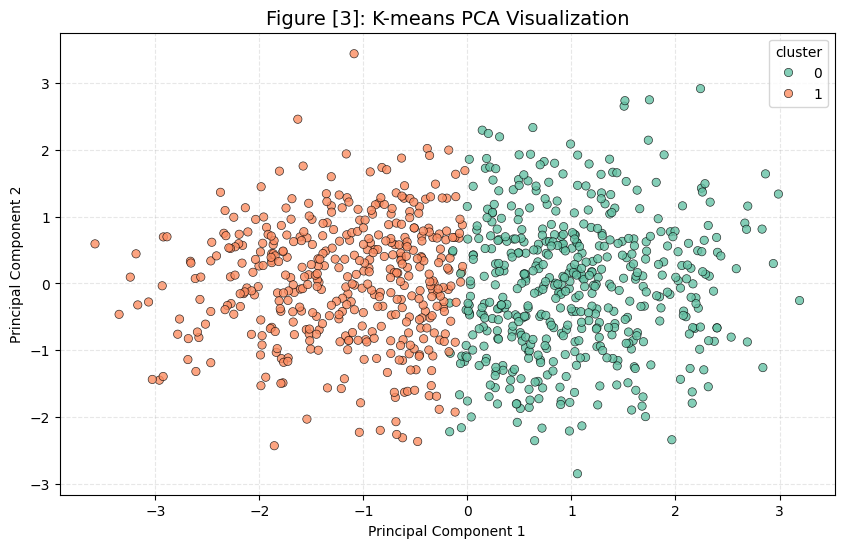

In [127]:
# Initialize PCA
pca = PCA(n_components=2, random_state=42)

# Transform the data
pca_components = pca.fit_transform(clustering_data)

# Save results to dataframe for plotting
patient_data['pca_1'] = pca_components[:, 0]
patient_data['pca_2'] = pca_components[:, 1]

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca_1', 
    y='pca_2', 
    hue='cluster', 
    data=patient_data, 
    palette='Set2', 
    edgecolor='black',
    alpha=0.8
)

plt.title('Figure [3]: K-means PCA Visualization', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Remove PCA columns after visualization
patient_data.drop(columns=['pca_1', 'pca_2'], inplace=True)

The PCA visualization presents the distribution of the two clusters in a two-dimensional space. While a general separation between the clusters is observable, the boundaries remain close and partially overlapping, indicating limited distinction between groups. The clusters appear somewhat “blended” near the center, with no clear gap separating them. Additionally, the clusters are not highly compact, as data points within each cluster are relatively dispersed rather than forming dense, well-defined groupings. This suggests moderate intra-cluster cohesion. These observations are consistent with the relatively low Silhouette Score (~0.19), which indicates weak but existing separation between clusters. However, the presence of a visible overall split supports the selection of k = 2, suggesting that the dataset contains a broad underlying structure rather than multiple well-separated subgroups.

#### **ii. T-distributed Stochastic Neighbor Embedding (t-SNE)** 

t-SNE is a non-linear dimensionality reduction technique designed to capture the local structure of high-dimensional data. It works by converting pairwise Euclidean distances between data points into joint probability distributions, representing similarities in the high-dimensional space. It then maps the data into a lower-dimensional space by minimizing the Kullback–Leibler (KL), which means it tries to make the new representation preserve the same similarities between data points as in the original space. This process preserves local relationships, making t-SNE particularly effective for visualizing clusters and complex non-linear patterns. Unlike PCA, which is a linear technique that projects data onto directions of maximum variance, t-SNE focuses on preserving local neighborhood structures rather than global variance. As a result, PCA provides a more stable and interpretable transformation, while t-SNE offers better visualization of non-linear cluster structures.

However, t-SNE is a stochastic algorithm, meaning that results can vary between runs unless a random seed is fixed. It is also sensitive to hyperparameters such as perplexity and learning rate, which can significantly affect the output. Additionally, t-SNE does not preserve global distances, making it unsuitable for measuring true relationships between clusters. It is primarily a visualization tool and should not be used for downstream tasks such as clustering or feature importance analysis.

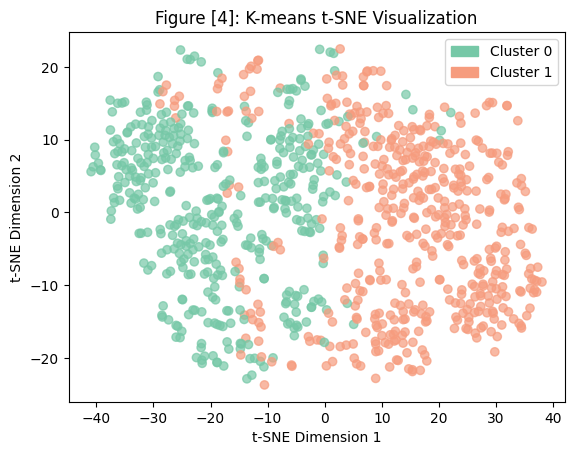

In [111]:
tsne = TSNE(
    n_components=2,          # Better for binary-heavy data visualization
    perplexity=40,           # Balanced for ~900 samples
    learning_rate='auto',    # Keeps the optimization stable
    max_iter=1000,           
    random_state=42
)

X_tsne = tsne.fit_transform(clustering_data)

# Colors
color_map = {
    0: "#76c8a7",  
    1: "#f69c7e",  
}

colors = [color_map[c] for c in clusters]

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Figure [4]: K-means t-SNE Visualization")

# Legend
handles = [
    mpatches.Patch(color=color_map[i], label=f'Cluster {i}')
    for i in range(2)   # Fixed: only 2 clusters
]

plt.legend(handles=handles)
plt.show()

As shown in *Figure 4*, the t-SNE projection provides a two-dimensional representation of the clustered dataset, enabling visual inspection of cluster separation and local structure. Overall, the clusters exhibit partial but meaningful separation.

Cluster 0 is primarily distributed on the left-hand side of the plot, forming a relatively coherent grouping that indicates internal similarity among its data points. Cluster 1, on the other hand, is mostly concentrated on the right-hand side, also showing a distinguishable structure. However, a noticeable overlap exists between the two clusters, particularly in the central regions, where data points from both groups are intermingled. This suggests that while the clusters capture a general underlying separation in the data, the boundary between them is not sharply defined. Overall, the visualization indicates moderate clustering structure, with some degree of shared characteristics between the two groups.


### **4.c Feature Importance Per Cluster**

Feature importance refers to identifying and ranking the features that most influence a model’s behavior. In clustering, it aims to determine which variables are most important in defining the structure of the clusters, despite the absence of true labels. 
To interpret the clusters generated by K-Means, a centroid-based approach was adopted, inspired by interpretable clustering techniques such as those discussed in “Interpretable K-Means Clusters Feature Importances” (Towards Data Science). This approach evaluates feature importance by analyzing the position of each cluster centroid in the feature space.

Feature importance was estimated using standardized centroid deviation, where the difference between each cluster centroid and the global dataset mean was normalized by the feature’s standard deviation. This provides a scale-independent measure of how strongly each feature differentiates a cluster from the overall data distribution. Since each centroid represents the mean profile of its cluster (MacQueen, 1967), features with larger standardized deviations indicate stronger contribution to defining the cluster. These features correspond to dimensions along which the cluster is most distinct relative to the dataset. This provides a fully unsupervised and interpretable method for estimating feature importance, as it relies directly on centroid representations without requiring external models.

> https://medium.com/%40a.cervantes2012/interpreting-and-validating-clustering-results-with-k-means-e98227183a4d?utm_source=chatgpt.com "Interpreting and Validating Clustering Results with K-Means"


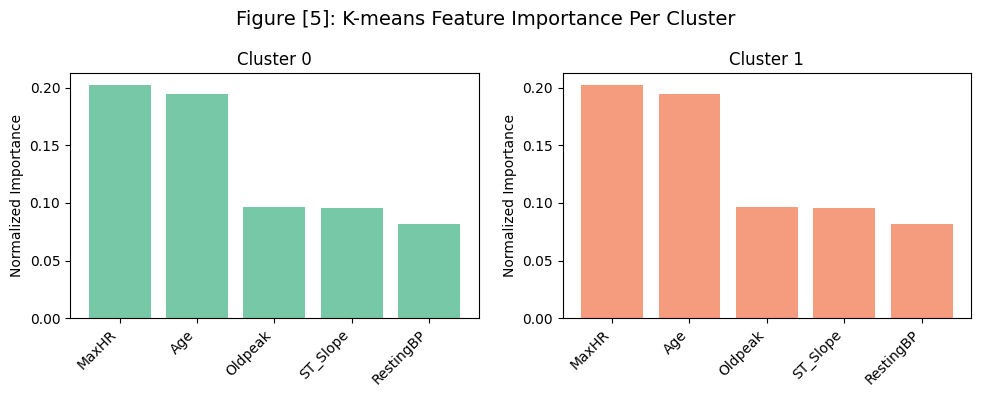

In [112]:
# Centroid-Based Feature Importance (Normalized Deviation)
# Convert dataset to NumPy array for numerical operations
X_values = clustering_data.values

# Extract final cluster centroids from the trained K-Means model
final_centroids = kmeans_final.cluster_centers_

# Compute the global mean of the dataset (reference point)
global_mean = np.mean(X_values, axis=0)

# Compute absolute deviation of each centroid from the global mean
# This measures how much each cluster differs from the overall dataset per feature
abs_movement = np.abs(final_centroids - global_mean)


# Get feature names (handles both DataFrame and NumPy cases)
feature_names = clustering_data.columns if hasattr(clustering_data, "columns") else [f"Feature {i}" for i in range(clustering_data.shape[1])]

# Dictionary to store feature importance per cluster
feature_importance = {}

# Loop over each cluster
for i in range(k_optimal):
    # Get deviation values for current cluster
    vals = abs_movement[i]
    
    # Normalize values so they sum to 1 (relative importance)
    vals_norm = vals / vals.sum()
    
    # Sort features by importance (descending order)
    sorted_idx = np.argsort(vals_norm)[::-1]

    # Store sorted feature importance as (feature_name, importance_score)
    feature_importance[i] = [
        (feature_names[j], vals_norm[j]) for j in sorted_idx
    ]

k = k_optimal # Number of clusters
top_n = 5 # Number of top features to display per cluster

# Create subplots (1 row, k columns)
fig, axes = plt.subplots(1, k, figsize=(5*k, 4))
warnings.filterwarnings("ignore")

# Fix: ensure axes is iterable when k = 2 (or even k = 1)
if k == 1:
    axes = [axes]

# Plot each cluster in its subplot
for i, ax in enumerate(axes):
    features, values = zip(*feature_importance[i][:top_n])
    
    ax.bar(features, values, color=color_map.get(i))
    ax.set_title(f"Cluster {i}")
    ax.set_xticks(range(len(features))) 
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_ylabel("Normalized Importance")

# Overall figure title (update number!)
fig.suptitle("Figure [5]: K-means Feature Importance Per Cluster", fontsize=14)

plt.tight_layout()
plt.show()

Across both clusters, the most consistently influential features are MaxHR, Age, Oldpeak, ST_Slope, and RestingBP, as they repeatedly appear among the top-ranked variables. This indicates that these features form the core dimensions along which the clusters are differentiated.

**Cluster 0** is primarily characterized by MaxHR and Age, indicating that variations in maximum heart rate and age play a major role in defining this group. Additional contributions from Oldpeak, ST_Slope, and RestingBP suggest that multiple cardiovascular indicators collectively shape the cluster profile.

**Cluster 1** is influenced by a very similar set of features, particularly MaxHR and Age, with secondary contributions from Oldpeak, ST_Slope, and RestingBP. The similarity in feature importance across both clusters indicates that the distinction between them is not based on different variables, but rather on differences in the values of these shared features.

 Overall, the dominance of MaxHR, Age, Oldpeak, and RestingBP suggests that the clustering structure is primarily driven by continuous physiological variables. The similarity in feature importance across clusters further indicates that the dataset does not contain entirely distinct subgroups defined by different attributes, but rather reflects gradual variation along the same key clinical dimensions. This is consistent with the weak but observable clustering structure identified earlier

### **4.d Cluster size distribution**

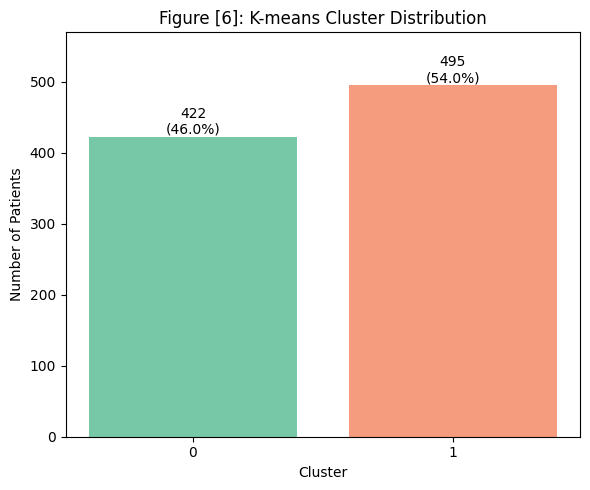

In [116]:
# Count samples per cluster
cluster_counts = patient_data['cluster'].value_counts().sort_index()

# Total samples
total = len(patient_data)

# Using our predefined color_map
colors = [color_map[i] for i in cluster_counts.index]

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)

# Titles and labels
plt.title('Figure [6]: K-means Cluster Distribution')  # updated figure number
plt.xlabel('Cluster')
plt.ylabel('Number of Patients')

# Optional: dynamic y-limit instead of fixed 400
plt.ylim(0, max(cluster_counts.values) * 1.15)

# Add values and percentages on bars
for i, count in enumerate(cluster_counts.values):
    percentage = (count / total) * 100
    plt.text(cluster_counts.index[i], count,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom')

plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

The cluster distribution shown in *Figure 6* reveals a relatively balanced split between the two clusters, with approximately 46% and 54% of the samples assigned to Cluster 0 and Cluster 1, respectively.

Interestingly, this distribution closely aligns with the original class distribution of the dataset, where patients were labeled as either having heart disease or not. Although the clustering process was performed in an unsupervised manner without using the target variable, the similarity in proportions suggests that the model has successfully captured an underlying structure consistent with the true data distribution. This alignment provides additional support for the validity of the clustering results, indicating that the identified clusters are not arbitrary but reflect meaningful patterns inherent in the dataset. Overall, the cluster distribution supports the validity of the chosen number of clusters and indicates that the model has captured a stable partitioning of the dataset.

## **Section.5 Cluster Interpretation & Profiles**

## **5.1 Cluster Profiles**

Cluster profiling is the process of translating the mathematical centers (centroids) of each group into descriptive human personas. By analyzing the mean values of features within each segment, we can identify the specific personality of a cluster determining which traits are dominant, which are rare, and how each group deviates from the population average. This step moves beyond simple grouping to explain the clinical and demographic logic behind why these specific patients were clustered together, transforming raw data into identifiable patient segments.

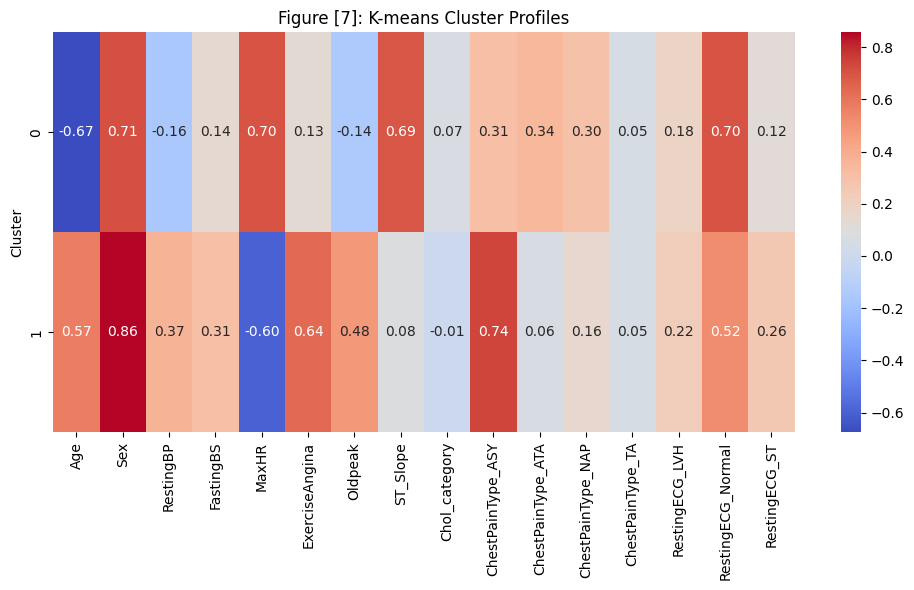

In [117]:
# Compute mean values of features for each cluster
cluster_profiles = patient_data.groupby('cluster').mean()

# Display the profiles
cluster_profiles

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure [7]: K-means Cluster Profiles")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

### **i. Cluster 0: Descriptive Profile**

| Category         | Attribute        | Metric (Z-score / %) | Descriptive Interpretation                                                                  |
| :--------------- | :--------------- | :------------------- | :------------------------------------------------------------------------------------------ |
| **Demographics** | Age              | `-0.67`              | Below the dataset mean (~53), indicating a younger population segment.                      |
|                  | Sex (Male)       | `69%`                | Predominantly male representation within the cluster.                                       |
| **Vitals**       | Resting BP       | `-0.10`              | Slightly below the average (~132 mmHg), indicating relatively stable blood pressure levels. |
|                  | Max Heart Rate   | `0.84`               | Well above the mean (~136 bpm), suggesting strong cardiovascular responsiveness.            |
| **Clinical**     | Oldpeak          | `-0.17`              | Below the average (~0.88), indicating reduced ST depression during exertion.                 |
|                  | Fasting BS       | `13%`                | Low prevalence compared to the dataset distribution.                                        |
| **Symptoms**     | Chest Pain (ASY) | `39%`                | Most common presentation is asymptomatic chest pain.                                        |
|                  | Chest Pain (ATA) | `30%`                | Secondary prevalence of atypical angina.                                                    |
| **Tests**        | Resting ECG      | `69%`                | High proportion of normal ECG readings.                                                     |
|                  | Exercise Angina  | `9%`                 | Minimal occurrence during physical activity.                                                |
|                  | ST Slope (Up)    | `78%`                | Strong dominance compared to other slope categories.                                        |
| **Lipids**       | High Chol        | `44%`                | Most frequent lipid category within this cluster.                                           |

> **Observation:** Cluster 0 represents a younger, physiologically responsive population. The combination of elevated **Max Heart Rate (`0.84`, above mean ~136 bpm)** and a dominant **upward ST slope (`78%`)** suggests stronger cardiovascular performance and recovery relative to the overall dataset.


### **ii. Cluster 1: Descriptive Profile**

| Category         | Attribute             | Metric (Z-score / %) | Descriptive Interpretation                                                                |
| :--------------- | :-------------------- | :------------------- | :---------------------------------------------------------------------------------------- |
| **Demographics** | Age                   | `-0.07`              | Approximately aligned with the dataset mean (~53), indicating an average-aged population. |
|                  | Sex (Male)            | `88%`                | Strongly male-dominated cluster.                                                          |
| **Vitals**       | Resting BP            | `-0.40`              | Below the average (~132 mmHg), indicating relatively lower blood pressure.                |
|                  | Max Heart Rate        | `-0.72`              | Significantly below the mean (~136 bpm), suggesting reduced cardiovascular capacity.      |
| **Clinical**     | Oldpeak               | `0.22`               | Slightly above average (~0.9), indicating mild ST depression.                             |
|                  | Fasting BS            | `28%`                | Moderate prevalence of elevated fasting blood sugar.                                      |
| **Symptoms**     | Chest Pain (ASY)      | `77%`                | Dominant presentation is asymptomatic chest pain.                             |
| **Tests**        | Resting ECG (Normal)  | `68%`                | Majority show normal ECG patterns at rest.                                                |
|                  | Exercise Angina       | `59%`                | Elevated occurrence during exertion, indicating functional cardiac limitation.            |
|                  | ST Slope (Flat)       | `68%`                | Predominant flat ST slope, associated with less favorable cardiac response.               |
|                  | ST Slope (Up)         | `22%`                | Lower proportion of upward slope patterns.                                                |
| **Lipids**       | Desirable Cholesterol | `55%`                | Slight dominance of desirable cholesterol levels, though other categories remain present. |

---

> **Observation:** Cluster 1 represents a **moderate-to-high cardiovascular risk group**. Despite largely normal resting ECG patterns, the combination of **reduced Max Heart Rate (`-0.72`)**, **elevated Exercise Angina (`59%`)**, and a **dominant flat ST slope (`68%`)** suggests impaired cardiac performance under stress conditions.


## 5.2 Domain Relation

--- 



## **Section 6. Integration Strategy**

### Integration Feasibility and Justification

While k-means clustering was explored and implemented, it was not selected for direct integration into the advice system. This decision is primarily due to the supervised learning approach adopted in Phase 1, which provided more reliable and interpretable predictions where it is considered as an essential requirement for a generative AI-based medical advice system. In contrast, the clustering results showed limited separation between groups and significant overlap in patient characteristics, as discussed in Section [4], making them less suitable for precise decision-making or user-facing recommendations.

However, this does not render the clustering model without value. The clustering component can serve as a supplementary feature to enhance the contextual understanding of the generative AI advice system. For instance, cluster membership may be incorporated as an additional input to guide more personalized and context-aware advice generation, complementing the predictions derived from the supervised learning model. However, given the relatively low silhouette score, the clustering structure should be interpreted with caution and used only as a weak contextual signal rather than a definitive grouping. This approach is consistent with established practices in machine learning, where unsupervised techniques are used for feature enrichment and to provide additional structure to downstream models (Bengio et al., 2013).

> Bengio, Y., Courville, A., & Vincent, P. (2013). *Representation Learning: A Review and New Perspectives*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 35(8), 1798–1828.

----

## **Section 7. Challenges & Limitations**

The application of k-means clustering to the heart disease dataset revealed three key challenges. First, as illustrated in Figure 1, determining the optimal number of clusters (k) was ambiguous, as the elbow point was not clearly identifiable, introducing uncertainty into the model selection process. Second, the dataset exhibited significant overlap in patient characteristics, reflecting the continuous nature of cardiovascular risk, which resulted in weak separation between clusters as observed in visualizations using Principal Component Analysis and t-distributed Stochastic Neighbor Embedding. Third, interpreting the resulting cluster profiles posed a challenge, as translating statistical feature averages into meaningful medical insights required additional domain understanding and research. Together, these challenges highlight both the methodological limitations of k-means and the complexity of working with real-world clinical data, suggesting that future work may benefit from alternative clustering approaches or enhanced feature engineering techniques.

---

# **HDBSCAN**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is HDBSCAN Algorithm?**

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that builds a hierarchy of clusters based on density. It is an extension of the DBSCAN method, which is a density-based clustering method. However, DBSCAN struggles with the assumption of global density, meaning it uses the same density threshold for all clusters. This often does not comply with medical datasets or many real world datasets in general , where clusters may have varying densities and sizes. Unlike DBSCAN, HDBSCAN can identify these variations effectively.

One of the most interesting features of the HDBSCAN algorithm is its ability to decide the optimal number of clusters while remaining robust to noise and outliers. These outliers are prevalent in our medical dataset and cannot be ignored, as they may represent significant clinical cases. This process of selecting the appropriate number of clusters is handled systematically by examining cluster stability across various density thresholds.


### **How does it work?**

The HDBSCAN algorithm consist of two phases:

- ***Mutual Reachability Graph***\
The algorithm starts by computing the core distance $d_c$ for all points. This represents the distance between a point $x_p$ and its $n$-th nearest neighbor $x_{s}, where $n$ is defined by the `min_samples` parameter. The smaller core distance the more points near to it the more density spot the point in. It calculated by the following formula:  $$d_c(x_p) = d(x_p, x_s)$$\
Then it calculates the mutual reachability distance $d_m$ between every pair points using the following formula: $$d_m(x_p, x_q) = \max \{d_c(x_p), d_c(x_q), d(x_p, x_q)\}$$ By taking the maximum, the algorithm effectively spreads out points that are in sparse regions.Thus, even if two points are close to each other. if one of them is in a low-density spot (large $d_c$), the mutual reachability distance between them will be larger. This gives a small distance between points that are both close to each other and located in high-density regions.\
After the computing mutual reachability distances, the algorithm builds the mutual reachability graph $G_{ms}$, where each data point represented as a vertex, and the edges between points represent the mutual reachability distance between them.

- ***Hierarchical Clustering***\
As we mentioned before, the HDBSCAN finds the appropriate number of clusters by examining clusters stability across various density thresholds **$\epsilon$**. This gives all connected parts for all **$\epsilon$** values. This done as the following:
1. Extracting a minimum spanning tree (MST) of $G_{ms}$, that is the subset of edges that connects all vertices together, without any cycles, and with the minimum possible total edge weight.
2. Adding a "self edge" for each vertex on the MST with a weight equals to its core distance.
3. Create a single cluster that contains the whole MST.
4. Finding the edges with the greatest weight (core distance) and remove them to splits the vertex groups connected with a weak edge, generating two **connected components**.
5. Labeling the connected components (clusters).
    1. If a connected component contains only one vertex (no edge) or less than `min_cluster_size` parameter if specified, label it as null (noise).
    2. If a connected component contains more than one vertex label it as a new cluster.
6. Repeat 4-5 until there are no more connected components (clusters become stable).

### **Why is HDBSCAN suitable for our data?**

#### i. Dataset size & feature types

The HDBSCAN algorithm affected by high-dimensional spaces (50-100 features) and can result in curse of dimensionality unless dimensionality reduction techniques applied [-], however our dataset were shrink after performing multiple experiments by researchers to includes only the top 20 important features as their consequences (other illnesses) affects the heart disease [-]. Consequently, dimensionality is not a concern, as 20 features does not considered high-dimensional and as our sample size ($N = 917$) exceeds the recommended 10–20 times the number of features.

It is also capable of handling mixed data types including both continuos and categorical features as long as the categorical features are appropriately preprocessed (e.g., One-Hot Encoding for nominal data and Label Encoding for ordinal data). Our preprocessing pipeline has already addressed these requirements, making HDBSCAN suited for our dataset.

The HDBSCAN algorithm considered a good choice for complex datasets like our medical dataset, as it is able to handle sparse clusters with varying shapes and densities of patients. These variations results from the various combinations of features that leads to herat disease and other diseases that can result from those combinations and cause a heart disease, some of those caused combinations have a high density ( combinations associated with high occurrence heart disease cause like Diabetes) others can have low density ( unpopular heart disease causes and conditions), the HDBSCAN can handle this density variation problem and not only specify a single density threshold.

---

#### ii. Expected cluster shapes

---

#### iii. Scalability & interpretability

## Section 2: Cluster Determination & Implementation

### 2.1 Determine the optimal parameters of clusters

- **Scalability** \
In the theoretical explanation of HDBSCAN algorithm, the process of finding the nth-nearest neighbor (used to computed the core distance) is expensive with a time complexity of O($n_2$), since it compute the distances between all pairs of points. However, the implementation can be optimize to approximately O(n log n) using KD-trees for low-dimensional data (less than 20). As the dimensionality increases, the efficiency of KD-trees degrades due to the Curse of Dimensionality, and alternatives such as Ball Trees are used, although performance still worsens with higher dimensions. \
\
 Another theoretical complexity is building a graph that contains all edges ( based on mutual reachability distances), it take O($n_2$) as every vertex should be connected to every other vertexes. To optimize this, the algorithm use MST tree (Minimum Spanning Tree ) that contains the minimum set of edges that dropping any edge results in disconnected components (no cycles), and this set of edges should contains the minimum total wights. \
 \
  To further improve efficiency, the MST is not built over the full graph, but instead it built over a k-nearest neighbor graph, significantly reducing the number of edges. Additionally, the implementation uses Borůvka's algorithm (or its optimized variants), which has a time complexity of approximately O(|E| log |V|) in the worst case, where |E| is the number of edges and |V| is the number of vertices. \
  \
  This gives an approximately total time complexity O(n log n) for low-dimensional data which our dataset is around, but it can degrade toward O($n_2$) in high-dimensional spaces.

- **Interpretability**  \
The Interpretability in clustering algorithms defined by the ability to understanding the structure of clusters and their formation. The HDBSCAN algorithm produces a hierarchical structure and identifies noise. This hierarchical organization can facilitate interpretation by allowing users to explore clusters at different levels of granularity. However, it does not provide simple representations such as centroids. \
\
The hierarchical structure of clusters and noise identification is important for our dataset, as it helps in associating different types of patients within a hierarchical framework, which gives a valuable insights into relationships between patient groups at multiple levels, while also identifying outliers that may represent important or unusual medical cases.

Unlike traditional centroid-based algorithms, HDBSCAN determines the optimal number of clusters automatically by calculating the stability of each potential cluster across various density thresholds [1]. However, the number of clusters is indirectly influenced by two key parameters:

* `min_cluster_size`: Sets a lower bound on the number of points required to form a cluster.
* `min_samples`: Determines the density threshold required for an area to be considered a cluster rather than noise. Higher values result in a more conservative clustering, leading to more points being declared as noise.[3]

Due to the complexity of medical datasets and the lack of sufficient domain expertise, we cannot pre-determine the optimal combination for these two attributes. Consequently, we will evaluate a range of possible combinations by measuring their DBCV (Density-Based Clustering Validation) scores, while ensuring that the noise ratio does not exceed 30% of the total data.

The best practice in hperparameters adjusments, is to assign 1-2% of the total dataset as min_cluster_size, and the half value as the starting point for the min_samples parameter.[1]




[3] https://hdbscan.readthedocs.io/en/latest/parameter_selection.html

[1] https://mbrenndoerfer.com/writing/hdbscan-hierarchical-density-based-clustering-automatic-cluster-selection


In [ ]:
import pandas as pd
import numpy as np
import hdbscan
import umap  
from sklearn.metrics import silhouette_score

hdbscan_data = clustering_data.copy()

results = []

min_samples_list = [5, 7, 10, 15, 20]
min_cluster_size_list = [9, 15, 20, 30, 40]

for ms in min_samples_list:
            for mcs in min_cluster_size_list:
            
                model = hdbscan.HDBSCAN(min_samples=ms, min_cluster_size=mcs, gen_min_span_tree=True)
                labels = model.fit_predict(hdbscan_data)

                n_clusters = len(set(labels) - {-1})
                noise_ratio = np.sum(labels == -1) / len(labels)


                mask = labels != -1
                if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
                    sil_score = silhouette_score(hdbscan_data[mask], labels[mask])
                else:
                    sil_score = np.nan

            
                if n_clusters > 1:
                    try:
                        dbcv_score = model.relative_validity_
                    except:
                        dbcv_score = np.nan
                else:
                    dbcv_score = np.nan

                results.append({
                    "min_samples": ms,
                    "min_cluster_size": mcs,
                    "n_clusters": n_clusters,
                    "noise_ratio": round(noise_ratio, 3),
                    "silhouette": round(sil_score, 4) if not np.isnan(sil_score) else np.nan,
                    "DBCV": round(dbcv_score, 4) if not np.isnan(dbcv_score) else np.nan
                })


results_df = pd.DataFrame(results).sort_values(by="DBCV", ascending=False).head(10)


results_df

,n_neighbors,n_components,min_samples,min_cluster_size,n_clusters,noise_ratio,silhouette,DBCV
5,30,15,10,25,5,0.516,0.6226,0.2369
6,30,15,10,30,4,0.516,0.6390,0.2347
7,30,15,10,35,3,0.552,0.6763,0.2334
8,30,15,10,40,3,0.552,0.6763,0.2334
0,30,15,5,25,7,0.543,0.3639,0.0112
1,30,15,5,30,7,0.543,0.3639,0.0112
2,30,15,5,35,6,0.579,0.3997,0.0112
3,30,15,5,40,5,0.578,0.3632,0.0110
4,30,15,5,50,4,0.469,0.5907,0.0108
14,30,15,15,50,2,0.552,0.8205,0.0006


Although the configuration with the highest DBCV score was considered, the selected model provides a better balance between cluster quality and separation. It achieves a high silhouette score (0.57), relatively low noise ratio (7%), and a reasonable number of clusters (6), making it more interpretable and stable.

### **Apply clustering and assign cluster labels**

In [35]:
final_reducer= umap.UMAP(n_neighbors=5, n_components=5, random_state=15)
X = final_reducer.fit_transform(hdbscan_data)

final_hdbscan = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=15, gen_min_span_tree=True)
labels = final_hdbscan.fit_predict(X)


### Visuallization 


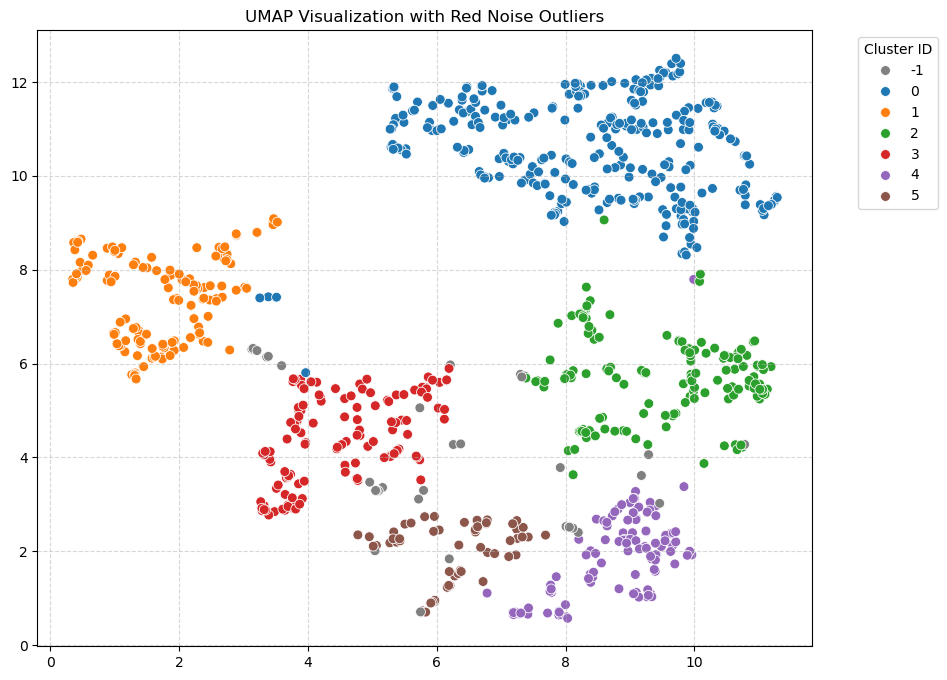

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import umap


reducer_2d = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    n_components=2,
    random_state=45
)

X_2d = reducer_2d.fit_transform(hdbscan_data) 



unique_labels = np.unique(labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

colors = []
for label in unique_labels:
    if label == -1:
        colors.append("#808080") 
    else:
        cluster_palette = sns.color_palette("tab10", n_colors=num_clusters)
        colors.append(cluster_palette[label])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=labels,
    palette=colors,
    hue_order=unique_labels,
    s=50,
            
)

plt.title("UMAP Visualization with Red Noise Outliers")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5) # إضافة شبكة خفيفة للرسم
plt.show()

In [ ]:

import hdbscan
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

hdbscan_data = clustering_data.copy()

results = []

min_samples_list = [5, 10, 15, 20, 30]
min_cluster_size_list = [25, 30, 35, 40, 50]

for ms in min_samples_list:
    for mcs in min_cluster_size_list:
        
        model = hdbscan.HDBSCAN(
            min_samples=ms,
            min_cluster_size=mcs,
            gen_min_span_tree=True
        )
        
        labels = model.fit_predict(hdbscan_data)  # ✅ مهم

        n_clusters = len(set(labels) - {-1})
        noise_ratio = np.sum(labels == -1) / len(labels)

        mask = labels != -1
        
        if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
            sil_score = silhouette_score(hdbscan_data[mask], labels[mask])
        else:
            sil_score = np.nan

        if n_clusters > 1:
            try:
                dbcv_score = model.relative_validity_
            except:
                dbcv_score = np.nan
        else:
            dbcv_score = np.nan

        results.append({
            "min_samples": ms,
            "min_cluster_size": mcs,
            "n_clusters": n_clusters,
            "noise_ratio": round(noise_ratio, 3),
            "silhouette": round(sil_score, 4) if not np.isnan(sil_score) else np.nan,
            "DBCV": round(dbcv_score, 4) if not np.isnan(dbcv_score) else np.nan
        })

results_df = pd.DataFrame(results).sort_values(by="DBCV", ascending=False).head(10)

results_df